# Fundamentals of Machine Learning

This first notebook is a tutorial on the fundamentals of machine learning. We will use the Scikit-learn library, which is one of the most popular machine learning libraries for Python. Assuming the library is correctly installed in your python environment, the following code allows to import the library so that we can use it.

In [1]:
import sklearn

## The problem setting

In general, a learning problem considers a set of $n$ samples of data and then tries to predict properties of unknown data.

In supervised learning, the data comes with additional variables that we want to predict (the output). If the output consists of one or more continuous variables, then the task is called regression. If the output has discrete values, then the task is called classification.

In unsupervised learning, the training data consists of a set of samples without any corresponding target values. The goal in such problems may be to discover groups of similar samples within the data, a.k.a. clustering, or to determine the distribution of data within the input space, a.k.a. density estimation, or to project the data from a high-dimensional space down to two or three dimensions for the purpose of visualization.

## Loading and preparing a dataset

Scikit-learn provides few small standard datasets that do not require to download any file from some external website (see https://scikit-learn.org/stable/datasets/toy_dataset.html). The following code loads the 'digits' dataset, which is a dataset of 8x8 pixel images of digits (0-9).

In [2]:
from sklearn import datasets

# load the digit dataset from the scikit-learn library:
digits = datasets.load_digits()

The `digits` object returned by the `load_digits` function is a dictionary-like object that holds the data and some metadata. The actual data and the metadata are accessed using the keys of this object:

In [3]:
# print the keys of the digits object, the data and target arrays and their shapes:

<span style="color:blue">Using the information contained in the `digits` object, can you define the underlying machine learning problem, by giving the type of problem it is (supervised, unsupervised, classification, regression, clustering, etc.) and of the nature of the inputs/outputs?</span>

Each sample in this dataset is an 8x8 image of a digit. The following code allows to visualize the first few images:

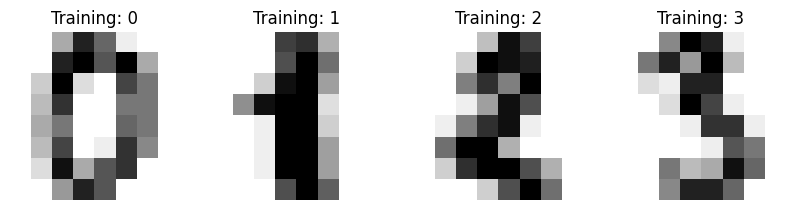

In [4]:
import matplotlib.pyplot as plt

def show_image(digits, img_idx, ax):
    ax.set_axis_off()
    ax.imshow(digits.images[img_idx], cmap=plt.cm.gray_r, interpolation="nearest")
    ax.set_title("Training: %i" % digits.target[img_idx])

_, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
for i in range(4):
    show_image(digits, i, axes[i])

Comment on the code: *Matplotlib is a plotting library. In this case, we use it to plot the first four images of the dataset. The `show_image` function displays the `img_idx`-th image of the dataset in a diagram `ax`. The first line of the code bellow creates a figure with 1 row and 4 columns. The second line is a for loop that iterates over the first four samples of the digits dataset. For each sample, we call the `show_image` function to plot the image in a subplot.*

<span style="color:blue">Using the previous code snippet as a guide, display several other random images to see several examples of each digit to be recognised. Do you find the problem easy or difficult (for a human)?</span>

## Learning and predicting

In the case of the 'digits' dataset, the task is to predict, given an image, which digit it represents. We are given samples of each of the 10 possible classes (0 to 9) on which we train a classifier to be able to predict the classes to which unseen samples belong.

Scikit-learn provides a wide range of supervised learning algorithms that all follow the same interface:
- an object that is the model (e.g., a classifier or a regressor),
- a `fit` method to train the model on the training data,
- a `predict` method that, given a trained model and a new set of data, predicts the labels of the new data.

In the following example, we use a classification method named 'k-Nearest Neighbors' (kNN) to learn the digits dataset. We leave out the last sample and use it to test the classifier:

[8]


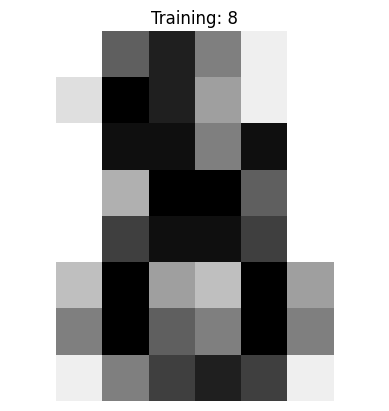

In [5]:
from sklearn.neighbors import KNeighborsClassifier

X = digits.data
y = digits.target

clf = KNeighborsClassifier(n_neighbors=5)

# Learn the digits on all the dataset but the last sample
clf.fit(digits.data[:-1], digits.target[:-1])

# Predict the class of the last sample, i.e. which digit it represents
predicted = clf.predict(digits.data[-1:])
print(predicted)

# Show the image of the last sample
_, ax = plt.subplots()
show_image(digits, -1, ax)

<span style="color:blue">Do you agree with the classifier?</span>

## Visualizing decision boundaries

For the purpose of visualization, we will now use a synthetic 2D classification dataset. Scikit-learn provides several artificial dataset generators, the one we are going to use is `make_moon`:

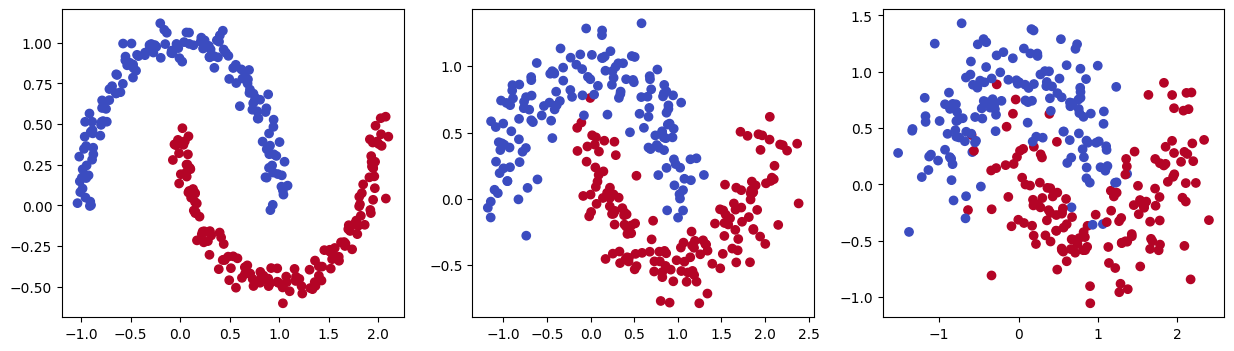

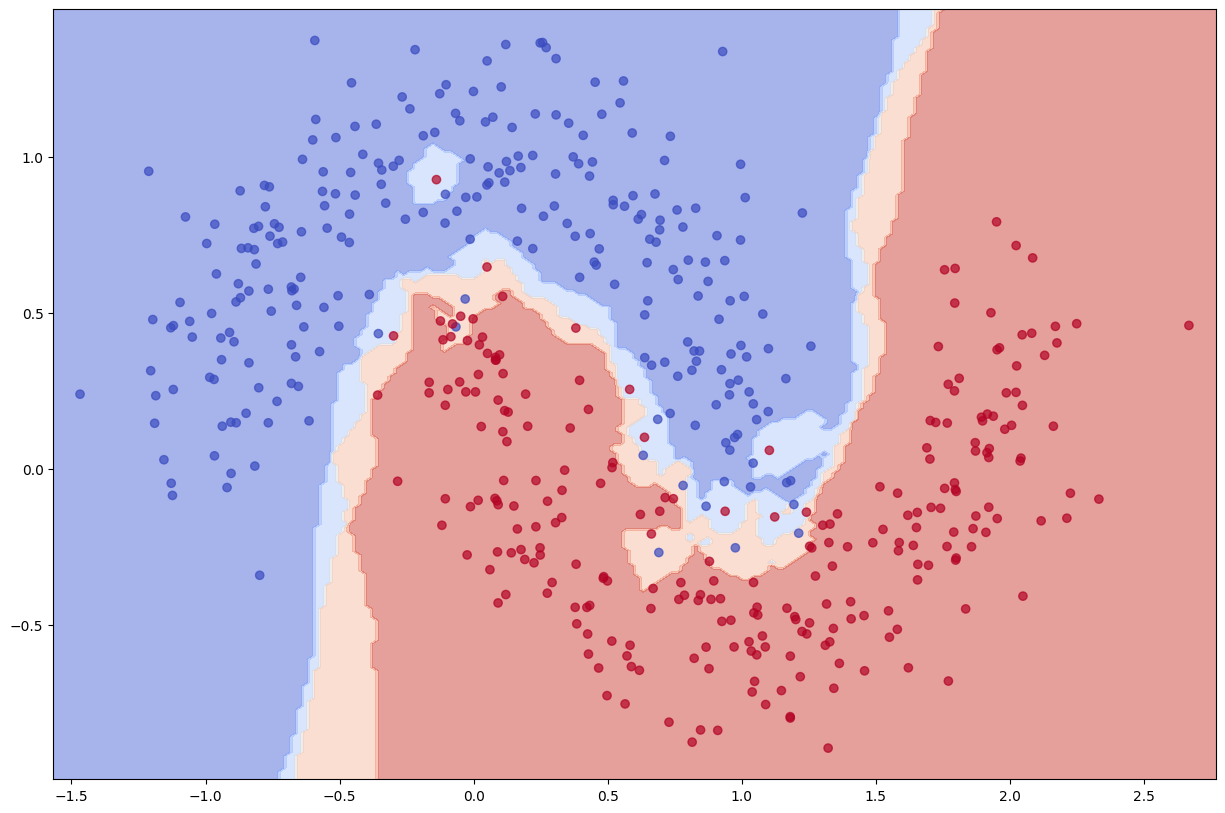

In [6]:
from sklearn.datasets import make_moons

X1, y1 = make_moons(n_samples=300, noise=0.05)
X2, y2 = make_moons(n_samples=300, noise=0.15)
X3, y3 = make_moons(n_samples=300, noise=0.25)

_, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))
axes[0].scatter(X1[:, 0], X1[:, 1], c=y1, cmap='coolwarm')
axes[1].scatter(X2[:, 0], X2[:, 1], c=y2, cmap='coolwarm')
axes[2].scatter(X3[:, 0], X3[:, 1], c=y3, cmap='coolwarm')

from sklearn.inspection import DecisionBoundaryDisplay

X, y = make_moons(n_samples=500, noise=0.2)
clf = KNeighborsClassifier(n_neighbors=3).fit(X, y)

_, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 10))
DecisionBoundaryDisplay.from_estimator(clf, X, cmap='coolwarm', alpha=0.5, ax=ax, eps=0.1, grid_resolution=200)
ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7)

<span style="color:blue">Taking inspiration from the previous example and exploring the scikit-learn documentation (https://scikit-learn.org/stable/datasets/sample_generators.html), generate another synthetic 2D problem, test and visualise the decision frontiers of a `k-nearest neighbour' classifier.</span>

## Evaluating model performance

To evaluate a machine learning model, the golden rule is to never test the model on data that it has learned. Most models can perfectly predict the outputs of data they have learned, but at the same time can fail to predict the outputs of unknown data. This is called **overfitting**. To avoid this, it is good practice to always keep some of the data aside, the **test set**, so that you can assess the model's ability to predict the output of unknown data.

Here again, Scikit-learn offers handy tools for dividing a dataset into two (or more) subsets:

Comment on the code: *The `train_test_split` function randomly splits the data into two subsets: the training set and the test set. The `test_size` parameter specifies the proportion of the data that should be in the test set. The `random_state` parameter is used to ensure that the split is always the same.*

We can now use the test set to evaluate the performance of the classifier we trained earlier:

<span style="color:blue">What do you think this score represents? Is it good or bad?</span>

The `n_neighbors` parameter of `KNeighborsClassifier` is a hyperparameter, that is to say a parameter that is not learned but that must be set by the user. The choice of its value can have a significant impact on the performance of the model. Most ML methods have such hyperparameters, and finding the best values for these hyperparameters is a crucial step in the design of a machine learning model. However, tuning hyperparameters by selecting the values that gives the best performance on the test set is a bad practice, as it can lead to *overfitting the test set*. To solve this problem, it is common to split the data into three subsets: the training set, the validation set, and the test set. The validation set is used to tune the hyperparameters, while the test set is used to evaluate the model's performance :

Comment on the code: *For setting the `n_neighbors` hyperparameter, we test each integer value in $[1, 20]$ and retain the one that gives the best score on the validation set. We plot the validation score w.r.t the `n_neighbors` value.*

<span style="color:blue">Why do you think the best score obtained here is different from the previous score?</span>

## Underfitting and Overfitting

One of the roles of hyperparameters is to be able to control the complexity of the model (a.k.a. its expressive power). This complexity can have a major impact on the model's generalisation capacity, i.e. its ability to correctly predict new data. A model that is too simple may not be able to capture the underlying structure of the data, a phenomenon called **underfitting**. On the other hand, a model that is too complex will tend to memorize the training data and will not be able to generalize to new data, a phenomenon called **overfitting**.

The following code illustrates the concept of underfitting and overfitting using a decision tree classifier. Tuning the `max_depth` hyperparameter of the `DecisionTreeClassifier` is one way to control the complexity of the model: the higher the value of `max_depth`, the more complex the model. By setting this hyperparameter from 1 to an arbitrarily high value, we can observe the two situations: underfitting is characterised by high learning and test errors, while overfitting is characterised by low learning error and high test error. 

<span style="color:blue">Can you give the value of `max_depth` that leads to the most underfitted model? and the one that lead to the most overfitted? In your opinion, what would be the best value for `max_depth`?</span>

<span style="color:blue">Taking inspiration from everything we've done in this tutorial, write a script below that solves the `load_digits` problem with a decision tree classifier, whose hyperparameters are those that maximise its generalisation performance. Don't forget to properly evaluate the performance of the final model.</span>